In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import AdamW
from tqdm.auto import tqdm
#from sklearn.metrics import confusion_matrix
#from sklearn.model_selection import training

In [11]:
# crop image function

def crop_image(img):
    '''crops, resizes, and grayscales images'''
    crop_box = (75, 75, 375, 375)
    cropped_img = img.crop(crop_box)
    cropped_img = cropped_img.resize((128,128)) #resize
    cropped_img = cropped_img.convert('L') #returns a black and white image
    return cropped_img

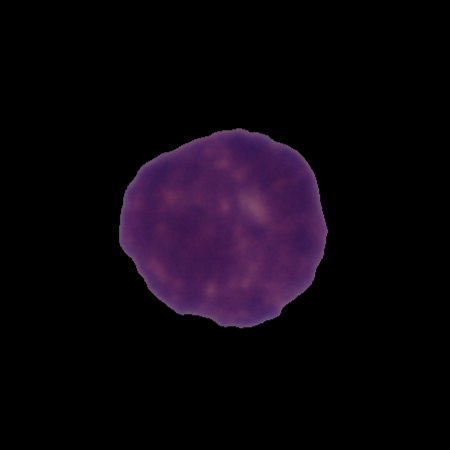

(450, 450)
(128, 128)


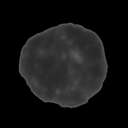

In [12]:
# checking that images have processed correcly
original = Image.open(r"C:\Users\piggi\Downloads\leukemia data\C-NMC_Leukemia\giant_input_folder\UID_11_14_1_all.bmp")
display(original)
print(original.size)

cropped = crop_image(original)
print(cropped.size)
display(cropped)

In [13]:
# array assignment function

def array_assignment(im):
    '''breaks image down to four dimensional input array and assigns ground truth label array'''
    (width, height) = (128,128)

    for x_pixel in range(width):
        for y_pixel in range(height):

            x[image_index, x_pixel, y_pixel] = im.getpixel((x_pixel,y_pixel))

    # assigns 0 to image if it does not have leukemia
    if "hem" in str(file_path):
        y[image_index] = 0

    # assigns 1 to image if it has leukemia
    elif "all" in str(file_path):
        y[image_index] = 1

    else: 
        pass
            

In [14]:
from pathlib import Path
from PIL import Image

#folder_path = Path("/Users/chloezeng/Documents/test png") #accesses folder with all our png images, CHLOES VERSION
folder_path = Path("C:/Users/piggi/Downloads/leukemia data/C-NMC_Leukemia/giant_input_folder") #SHANDIS VERSION
#png_files = folder_path.glob("*.png") #accesses individual file paths within our folder #CHLOES VERSION
bmp_files = folder_path.glob("*.bmp") #accesses individual file paths within our folder #SHANDIS VERSION

#x = np.empty((10661,300,300,3), dtype=np.uint8) #defines empty x (input) array
x = np.empty((10661,128,128), dtype=np.uint8) #FOR BLACK AND WHITE
y = np.empty((10661,), dtype=np.uint8) #defines empty y (ground truth/output) array

image_index = 0 #image number

for file_path in tqdm(bmp_files, desc="image processing progress"): #shandi's version
    with Image.open(file_path) as img:
    #opens all images sequentially
        
        cropped_image = crop_image(img) #crops out extra black background
        
        array_assignment(cropped_image) #extracts data from pictures

        image_index += 1


image processing progress: 0it [00:00, ?it/s]

In [15]:
print(y) 

#checking what proportion of the training data is healthy cells
counter = 0
for i in range (len(y)):
    if y[i] == 0:
        counter += 1
    else:
        pass
print(counter/len(y))  

[1 1 1 ... 0 0 0]
0.31788762780227


In [9]:
#defining the CNN model

model = Sequential()

model.add(Input(shape=(128,128,1)))
model.add(Conv2D(256, (2,2), activation='relu'))
model.add(MaxPooling2D((4,4)))
model.add(Conv2D(512, (2,2), activation='relu'))
#model.add(Flatten())
model.add(GlobalAveragePooling2D())
model.add(Dense(512, activation = 'relu'))
model.add(Dense(2, activation = 'softmax'))
model.summary()

model.compile(optimizer = AdamW(learning_rate=1e-3), 
              loss = 'sparse_categorical_crossentropy', 
              metrics = ['accuracy'])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 127, 127, 256)       │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 30, 30, 512)         │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 789,762 (3.01 MB)

 Trainable params: 789,762 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 403s 3s/step - accuracy: 0.6751 - loss: 0.6487 - val_accuracy: 0.7026 - val_loss: 0.5229
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 397s 3s/step - accuracy: 0.7792 - loss: 0.4980 - val_accuracy: 0.8096 - val_loss: 0.4819
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 390s 3s/step - accuracy: 0.7858 - loss: 0.4901 - val_accuracy: 0.8049 - val_loss: 0.4707
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 388s 3s/step - accuracy: 0.7866 - loss: 0.4817 - val_accuracy: 0.8124 - val_loss: 0.4664
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 390s 3s/step - accuracy: 0.7876 - loss: 0.4773 - val_accuracy: 0.8114 - val_loss: 0.4670
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 389s 3s/step - accuracy: 0.7887 - loss: 0.4739 - val_accuracy: 0.8077 - val_loss: 0.4611
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 363s 3s/step - accuracy: 0.7866 - loss: 0.4755 - val_accuracy: 0.8068 - val_loss: 0.4660
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7888 - loss: 0.4715 - val_accu

In [ ]:
#sets up stratified k-fold cross validation

from sklearn.metrics import balanced_accuracy_score

x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size = 0.1, random_state = 30)
x_test = x_test[..., np.newaxis]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=3)
accuracies = []

for train_index, val_index in skf.split(x_temp, y_temp):
    x_train, x_val = x_temp[train_index], x_temp[val_index]
    y_train, y_val = y_temp[train_index], y_temp[val_index]

    # fixing dimensional mismatch
    x_train = x_train[..., np.newaxis]
    x_val = x_val[..., np.newaxis]

    # fitting the model
    model.fit(x_train, y_train,
          epochs = 3,
          batch_size = 64, 
          validation_data = (x_val, y_val))
    
    #evaluating accuracy
    y_val_pred = model.predict(x_val)
    y_val_pred = tf.argmax(y_pred, axis=1).numpy()
    
    balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
    
    accuracies.append(balanced_acc)

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

print(accuracies)

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = model.predict(x_test)
y_pred_test = tf.argmax(y_pred_test, axis=1).numpy()

cm = confusion_matrix(y_test, y_pred_test)

balanced_acc = balanced_accuracy_score(y_val, y_pred)

print("Balanced validation accuracy:", balanced_acc * 100, "%")


34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step


ValueError: Found input variables with inconsistent numbers of samples: [3198, 1066, 3198]

In [6]:
# np.save("x_train", x_train)
# np.save("x_val", x_val)
# np.save("x_test", x_test)
# np.save("y_train", y_train)
# np.save("y_val", y_val)
# np.save("y_test", y_test)

In [20]:
# #testing if the code actually works

# print("Current folder:", Path.cwd())

# #folder_path = Path("/Users/chloezeng/Documents/test png") #chloes version
# folder_path = Path("C:/Users/piggi/Downloads/leukemia data/C-NMC_Leukemia/giant_input_folder") #shandis version
# print("Folder exists:", folder_path.exists())

# #png_files = list(folder_path.glob("*.png")) #chloe's version
# bmp_files = list(folder_path.glob("*.bmp")) #shandi's version
# print("Number of files:", len(bmp_files)) #shandi's version

Current folder: C:\Users\piggi\Downloads\leukemia-cnn-project-spis-2026-chloe-shandi
Folder exists: True
Number of files: 10661


In [ ]:
# #splits data into training, validation, and testing sets 80-10-10
# x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size = 0.2, random_state = 30)
# x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size = 0.5, random_state = 67) 

# x_train = x_train[..., np.newaxis]
# x_val = x_val[..., np.newaxis]
# x_test = x_test[..., np.newaxis]

# print(x_train.shape)
# print(x_val.shape)
# print(x_test.shape)
# print(y_train.shape)
# print(y_val.shape)
# print(y_test.shape)